## Wi-Fi Network Congestion Prediction - Phase 1(EDA)


--- HEAD ---

   num_devices  latency  packet_loss  signal_strength  bandwidth  channel  \
0           39      105          5.9              -42          9        9   
1           29      189          0.6              -55         37        2   
2           15      122          5.6              -79         69        4   
3           43       71          3.5              -50         22        6   
4            8      195          4.4              -72         53        2   

   noise_level  throughput  upload_speed  download_speed  jitter  distance  \
0          -93          61            23              63      34        25   
1          -78          35            49              88      36        21   
2          -75          10             9              10       2        15   
3          -89          44            35              23      15         1   
4          -75          16            20              61      34        12   

   obstacles  router_load congestion_level  
0       

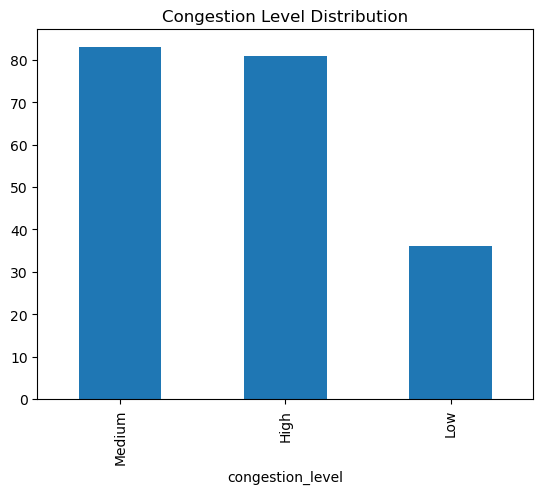

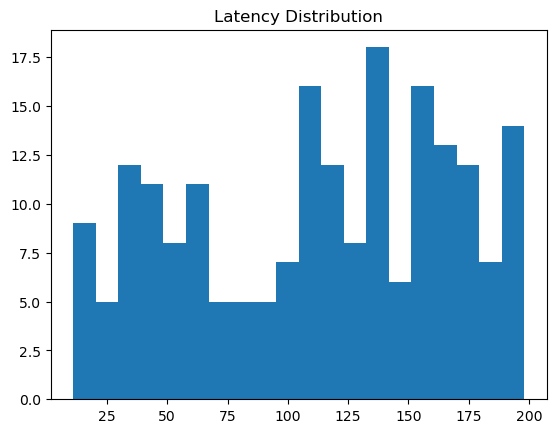

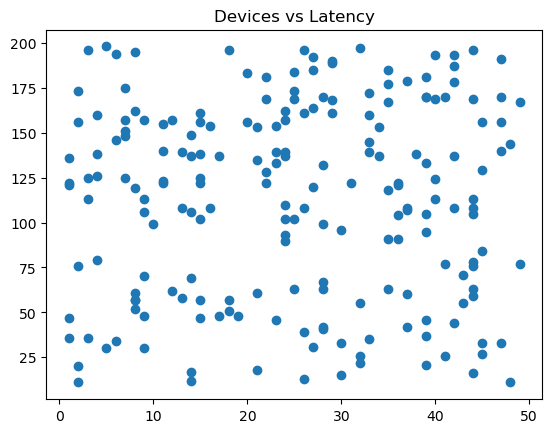

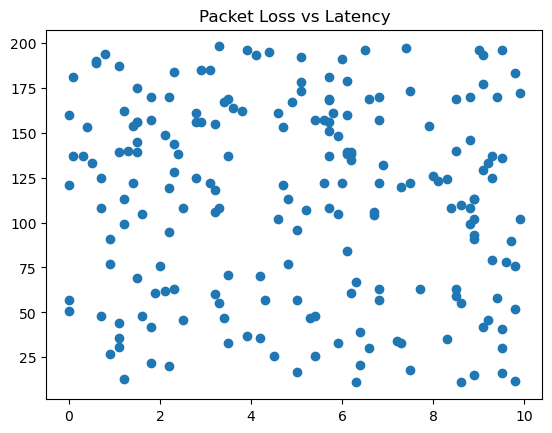

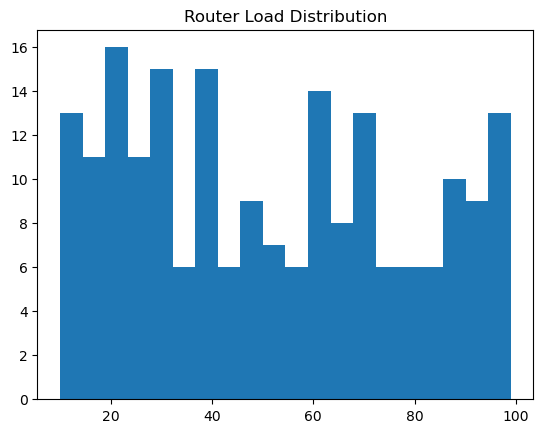

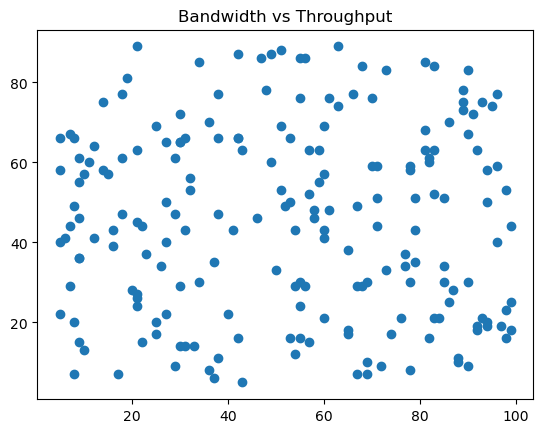

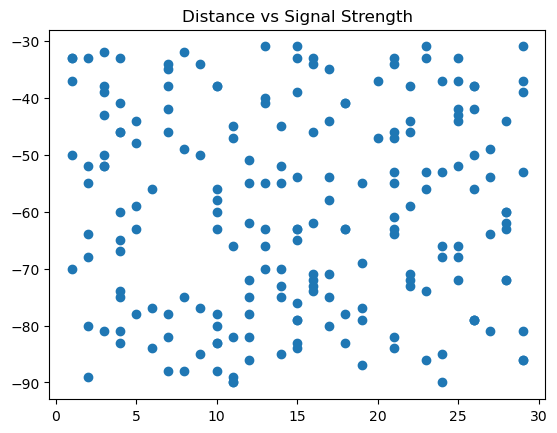

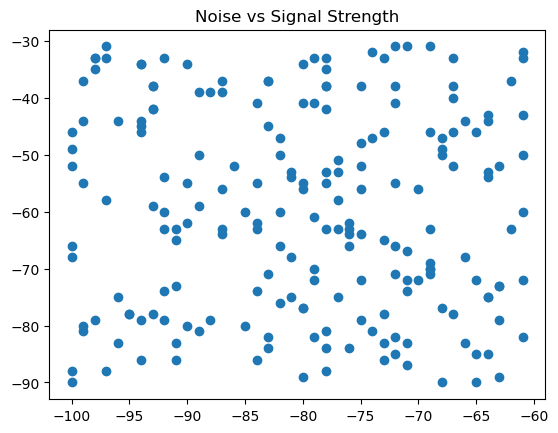

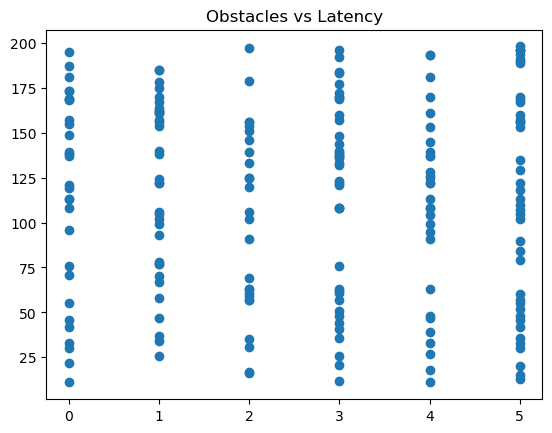

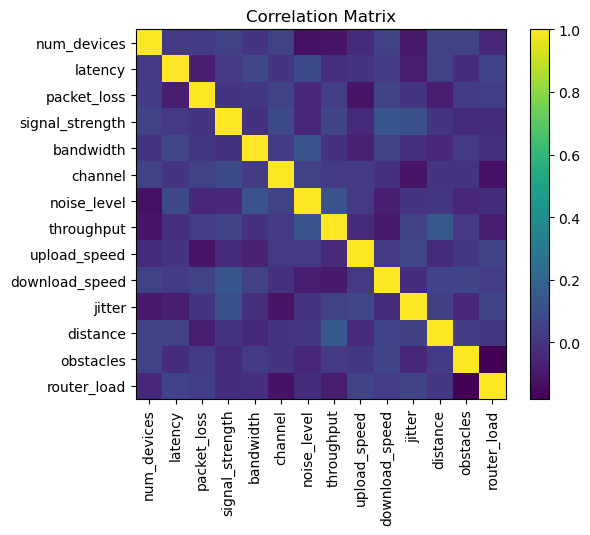

In [9]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================
# 2. DATA GENERATION
# ============================================

np.random.seed(42)
n = 200

data = {
    "num_devices": np.random.randint(1, 50, n).tolist(),
    "latency": np.random.randint(10, 200, n).tolist(),
    "packet_loss": (np.random.randint(0, 100, n) / 10).tolist(),
    "signal_strength": np.random.randint(-90, -30, n).tolist(),
    "bandwidth": np.random.randint(5, 100, n).tolist(),
    "channel": np.random.randint(1, 12, n).tolist(),
    "noise_level": np.random.randint(-100, -60, n).tolist(),
    "throughput": np.random.randint(5, 90, n).tolist(),
    "upload_speed": np.random.randint(1, 50, n).tolist(),
    "download_speed": np.random.randint(5, 100, n).tolist(),
    "jitter": np.random.randint(1, 50, n).tolist(),
    "distance": np.random.randint(1, 30, n).tolist(),
    "obstacles": np.random.randint(0, 6, n).tolist(),
    "router_load": np.random.randint(10, 100, n).tolist()
}


# ============================================
# 3. IMPROVED MULTI-FEATURE LOGIC
# ============================================

congestion = []

for i in range(n):
    
    score = 0
    
    # num_devices
    if data["num_devices"][i] > 30:
        score += 2
    elif data["num_devices"][i] > 20:
        score += 1

    # latency
    if data["latency"][i] > 120:
        score += 2
    elif data["latency"][i] > 80:
        score += 1

    # packet_loss
    if data["packet_loss"][i] > 5:
        score += 1

    # router_load
    if data["router_load"][i] > 70:
        score += 2
    elif data["router_load"][i] > 40:
        score += 1

    # noise_level
    if data["noise_level"][i] > -75:
        score += 1

    # final classification
    if score >= 5:
        congestion.append("High")
    elif score >= 3:
        congestion.append("Medium")
    else:
        congestion.append("Low")

data["congestion_level"] = congestion


# ============================================
# 4. CREATE DATAFRAME
# ============================================

df = pd.DataFrame(data)

print("\n--- HEAD ---\n")
print(df.head())


# ============================================
# 5. BASIC EDA
# ============================================

print("\n--- SHAPE ---\n", df.shape)

print("\n--- INFO ---\n")
print(df.info())

print("\n--- DESCRIBE ---\n")
print(df.describe())

print("\n--- MISSING VALUES ---\n")
print(df.isnull().sum())


# ============================================
# 6. CLASS DISTRIBUTION CHECK (IMPORTANT)
# ============================================

print("\n--- CLASS DISTRIBUTION ---\n")
print(df["congestion_level"].value_counts())


# ============================================
# 7. SAVE RAW DATA
# ============================================

df.to_csv("wifi_raw_data.csv", index=False)


# ============================================
# 8. OUTLIER REMOVAL (IQR)
# ============================================

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | 
                (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("\n--- OUTLIER REMOVAL ---\n")
print("Original:", df.shape)
print("After Cleaning:", df_clean.shape)


# ============================================
# 9. SAVE CLEANED DATA
# ============================================

df_clean.to_csv("cleaned_wifi_data.csv", index=False)


# ============================================
# 10. GRAPHS (10)
# ============================================

# 1
plt.figure()
df_clean["congestion_level"].value_counts().plot(kind="bar")
plt.title("Congestion Level Distribution")
plt.show()

# 2
plt.figure()
plt.hist(df_clean["latency"], bins=20)
plt.title("Latency Distribution")
plt.show()

# 3
plt.figure()
plt.scatter(df_clean["num_devices"], df_clean["latency"])
plt.title("Devices vs Latency")
plt.show()

# 4
plt.figure()
plt.scatter(df_clean["packet_loss"], df_clean["latency"])
plt.title("Packet Loss vs Latency")
plt.show()

# 5
plt.figure()
plt.hist(df_clean["router_load"], bins=20)
plt.title("Router Load Distribution")
plt.show()

# 6
plt.figure()
plt.scatter(df_clean["bandwidth"], df_clean["throughput"])
plt.title("Bandwidth vs Throughput")
plt.show()

# 7
plt.figure()
plt.scatter(df_clean["distance"], df_clean["signal_strength"])
plt.title("Distance vs Signal Strength")
plt.show()

# 8
plt.figure()
plt.scatter(df_clean["noise_level"], df_clean["signal_strength"])
plt.title("Noise vs Signal Strength")
plt.show()

# 9
plt.figure()
plt.scatter(df_clean["obstacles"], df_clean["latency"])
plt.title("Obstacles vs Latency")
plt.show()

# 10
plt.figure()
corr = df_clean.corr(numeric_only=True)
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()